# HRT Datathon 2026 — Solution

**Strategy:**
- Identify the 'owner' company per session (Igor's precomputed ensemble classifier)
- Extract keywords from ALL owner-matched seen headlines (not just the last), with recency weighting
- Build Kelly-criterion lookup table: keyword → expected return score
- **Position = 1 + γ × (kelly_agg / σ_kelly)** — always long, tilted by keyword signal
- Evaluate with 5-fold cross-validation to get unbiased OOF Sharpe

**Key insight:** Training data has strong positive drift (mean 2h return = +0.35%), so the optimal strategy is long-biased. Adding the keyword tilt (γ ≈ 0.4) pushes OOF Sharpe from 2.77 (always-long) to **2.88**.

## 1. Setup

In [3]:
import sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.model_selection import KFold
from scipy.stats import skew as scipy_skew

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

DATA = '../data'
IGOR = '../igor'

print('Python:', sys.executable)

Python: /Users/iliasmc/projects/hrt-datathon/.venv/bin/python


## 2. Load Data

In [4]:
bars_seen_train   = pd.read_parquet(f'{DATA}/bars_seen_train.parquet')
bars_unseen_train = pd.read_parquet(f'{DATA}/bars_unseen_train.parquet')
bars_seen_pub     = pd.read_parquet(f'{DATA}/bars_seen_public_test.parquet')
bars_seen_priv    = pd.read_parquet(f'{DATA}/bars_seen_private_test.parquet')

hl_seen_train = pd.read_parquet(f'{DATA}/headlines_seen_train.parquet')
hl_seen_pub   = pd.read_parquet(f'{DATA}/headlines_seen_public_test.parquet')
hl_seen_priv  = pd.read_parquet(f'{DATA}/headlines_seen_private_test.parquet')

# Igor's ensemble classifier: predicts the 'owner' company for all 21000 sessions
company_all   = pd.read_csv(f'{IGOR}/session_company_classifications_all.csv')
company_train = company_all[company_all['split']=='train'][['session','predicted_company']].reset_index(drop=True)
company_pub   = company_all[company_all['split']=='public_test'][['session','predicted_company']].reset_index(drop=True)
company_priv  = company_all[company_all['split']=='private_test'][['session','predicted_company']].reset_index(drop=True)

print('bars_seen_train  :', bars_seen_train.shape)
print('bars_unseen_train:', bars_unseen_train.shape)
print('bars_seen_pub    :', bars_seen_pub.shape)
print('bars_seen_priv   :', bars_seen_priv.shape)
print('hl_seen_train    :', hl_seen_train.shape)
print('company splits   : train=%d pub=%d priv=%d' % (len(company_train), len(company_pub), len(company_priv)))

bars_seen_train  : (50000, 6)
bars_unseen_train: (50000, 6)
bars_seen_pub    : (500000, 6)
bars_seen_priv   : (500000, 6)
hl_seen_train    : (9740, 3)
company splits   : train=1000 pub=10000 priv=9999


## 3. Ground Truth Labels

In [5]:
halfway = bars_seen_train[bars_seen_train['bar_ix']==49].set_index('session')['close'].rename('close_half')
end     = bars_unseen_train[bars_unseen_train['bar_ix']==99].set_index('session')['close'].rename('close_end')
target  = pd.concat([halfway, end], axis=1).reset_index()
target['ret2h']    = target['close_end'] / target['close_half'] - 1
target['direction'] = np.sign(target['ret2h'])

print(f"Training sessions: {len(target)}")
print(f"ret2h: mean={target['ret2h'].mean():.5f}  std={target['ret2h'].std():.5f}  "
      f"pct_positive={(target['ret2h']>0).mean():.3f}")
print()
print('NOTE: Strong positive drift in training data (mean +0.35%).')
print('Always-long baseline Sharpe ≈', round(target['ret2h'].mean()/target['ret2h'].std()*16, 3))

Training sessions: 1000
ret2h: mean=0.00353  std=0.02043  pct_positive=0.570

NOTE: Strong positive drift in training data (mean +0.35%).
Always-long baseline Sharpe ≈ 2.765


## 4. Keyword Table

50 headline templates discovered through EDA (see `igor/headlines_research.ipynb`). Each keyword maps to a characteristic 2nd-half return pattern.

In [6]:
KEYWORDS = [
    'completes planned facility upgrade',
    'warns of supply chain disruptions affecting',
    'wins industry award',
    'announces significant capital expenditure plan for',
    'withdraws from',
    'recalls products in',
    'reports rising costs pressuring margins',
    'completes strategic acquisition',
    'increase in customer acquisition',
    'loses key contract',
    'reports record quarterly',
    'names new',
    'decline in operating income',
    'secures',
    'expands operations into',
    'launches next-generation',
    'begins scheduled maintenance',
    'margin improvement',
    'drop in new customer orders this quarter',
    'reports strong demand in',
    'files routine',
    'files for regulatory',
    'explores strategic alternatives',
    'confirms participation',
    'delays product launch',
    'opens new office',
    'enters joint venture',
    'faces class action',
    'sees mixed results in',
    'board meeting',
    'misses quarterly revenue estimates',
    'faces regulatory review',
    'to host investor day focused on',
    'announces breakthrough in',
    'revises long-term strategy with focus on',
    'share buyback program',
    'signs multi-year partnership with a',
    'to present at',
    'announces restructuring plan',
    'reports unexpected decline in',
    'announces major organizational restructuring',
    'publishes annual sustainability report',
    'lowers full-year guidance amid softening demand',
    'addresses investor concerns in open letter',
    'steps down unexpectedly',
    'raises full-year guidance citing robust demand',
    'in talks for potential merger, details undisclosed',
    'achieves key regulatory milestone ahead of schedule',
    'beats analyst expectations with strong earnings growth',
    'schedules annual shareholder meeting for next month',
]

def extract_keyword(headline: str):
    hl = headline.lower()
    for kw in KEYWORDS:
        if kw in hl:
            return kw
    return None

print(f'{len(KEYWORDS)} keywords defined')

50 keywords defined


## 5. Feature Engineering

### 5a. Price Features

In [7]:
def extract_price_features(bars: pd.DataFrame) -> pd.DataFrame:
    bars = bars.sort_values(['session','bar_ix']).copy()
    bars['bar_ret'] = bars.groupby('session')['close'].pct_change()
    feats = []
    for sess, grp in bars.groupby('session'):
        grp = grp.sort_values('bar_ix')
        close = grp['close'].values; high = grp['high'].values
        low = grp['low'].values; rets = grp['bar_ret'].dropna().values
        n = len(close); open0 = grp['open'].iloc[0]
        vol_1h = rets.std() if len(rets) > 1 else 0.001
        def mom(nb): idx=max(0,n-1-nb); return close[-1]/close[idx]-1 if close[idx]>0 else 0.0
        h_max = high.max(); l_min = low.min(); rng = h_max - l_min
        slope = np.polyfit(np.arange(n), close/close[0], 1)[0] if n > 1 else 0.0
        early_ret = close[n//2-1]/open0-1 if n >= 2 else 0.0
        vov = float(pd.Series(np.abs(rets)).rolling(10, min_periods=5).std().iloc[-1]) if len(rets) >= 5 else 0.0
        feats.append({
            'session'        : sess,
            'ret_1h'         : close[-1]/open0 - 1,
            'vol_1h'         : vol_1h,
            'mom_5'          : mom(5), 'mom_10': mom(10), 'mom_20': mom(20),
            'close_in_range' : (close[-1]-l_min)/rng if rng > 0 else 0.5,
            'spread_mean'    : (high-low).mean(),
            'ret_skew'       : scipy_skew(rets) if len(rets) > 2 else 0.0,
            'slope'          : slope,
            'late_vs_early'  : mom(10) - early_ret,
            'vol_of_vol'     : vov if np.isfinite(vov) else 0.0,
        })
    return pd.DataFrame(feats)


price_feats_train = extract_price_features(bars_seen_train)
price_feats_pub   = extract_price_features(bars_seen_pub)
price_feats_priv  = extract_price_features(bars_seen_priv)

print('Price features (train):', price_feats_train.shape)
price_feats_train.head(3)

Price features (train): (1000, 12)


,session,ret_1h,vol_1h,mom_5,mom_10,mom_20,close_in_range,spread_mean,ret_skew,slope,late_vs_early,vol_of_vol
0,0,0.0316,0.002552,0.001456,0.004870,0.006832,0.940171,0.003924,-0.600199,0.000534,-0.027930,0.000885
1,1,0.0286,0.003388,-0.005415,-0.012576,-0.005319,0.738983,0.004760,0.242986,0.000986,-0.043376,0.001011
2,2,0.0208,0.003986,0.004131,0.007004,0.012799,0.873720,0.005298,-0.299658,0.000251,-0.004896,0.002355


### 5b. Headline Features — Owner Keyword Extraction

In [8]:
def extract_headline_features(headlines: pd.DataFrame, company_df: pd.DataFrame) -> pd.DataFrame:
    """
    For each session, find headlines from the owner company and extract keyword patterns.
    Returns a list of (bar_ix, keyword) pairs per session for flexible downstream aggregation.
    """
    hl = headlines.copy()
    hl['company_name'] = hl['headline'].str.split().str[:2].str.join(' ')
    hl['keyword']      = hl['headline'].apply(extract_keyword)
    hl = hl.merge(company_df, on='session', how='left')
    hl['is_owner']     = hl['company_name'] == hl['predicted_company']

    results = []
    for sess in headlines['session'].unique():
        sess_hl  = hl[hl['session']==sess].sort_values('bar_ix')
        owner_hl = sess_hl[sess_hl['is_owner']]
        owner_kw = owner_hl.dropna(subset=['keyword'])
        last_kw  = owner_kw.iloc[-1]['keyword'] if len(owner_kw) > 0 else None
        kw_list  = list(owner_kw[['bar_ix','keyword']].itertuples(index=False, name=None))
        results.append({
            'session' : sess,
            'n_owner' : len(owner_hl),
            'n_kw'    : len(owner_kw),
            'n_total' : len(sess_hl),
            'last_kw' : last_kw,
            'kw_list' : kw_list,
        })
    return pd.DataFrame(results)


hl_feats_train = extract_headline_features(hl_seen_train, company_train)
hl_feats_pub   = extract_headline_features(hl_seen_pub,   company_pub)
hl_feats_priv  = extract_headline_features(hl_seen_priv,  company_priv)

print('Headline features (train):', hl_feats_train.shape)
print('Sessions with ≥1 owner keyword:', (hl_feats_train['n_kw']>0).sum())
hl_feats_train[['session','n_owner','n_kw','last_kw']].head(5)

Headline features (train): (1000, 6)
Sessions with ≥1 owner keyword: 1000


,session,n_owner,n_kw,last_kw
0,0,3,3,faces class action
1,1,2,2,reports rising costs pressuring margins
2,2,2,2,misses quarterly revenue estimates
3,3,4,4,loses key contract
4,4,2,2,share buyback program


## 6. Keyword → Return Lookup Table

For each keyword, compute the Kelly-criterion score from training returns.

**Note:** Keywords with only 1 observation have `std_ret = NaN`; we substitute a conservative `std = 0.02` (≈ population std).

In [9]:
def build_keyword_lookup(hl_feats: pd.DataFrame, tgt: pd.DataFrame,
                          min_count: int = 5, clip_pct: float = 0.75) -> pd.DataFrame:
    merged = hl_feats[['session','last_kw']].merge(tgt[['session','ret2h']], on='session').dropna(subset=['last_kw'])
    stats  = (
        merged.groupby('last_kw')['ret2h']
        .agg(mean_ret='mean', std_ret='std', count='count')
        .assign(variance = lambda d: d['std_ret'].fillna(0.02) ** 2)  # handle single-obs keywords
        .assign(kelly    = lambda d: d['mean_ret'] / (d['variance'] + 1e-9))
    )
    nonzero_k = stats.loc[stats['kelly'].abs() > 0, 'kelly'].abs()
    clip_val  = nonzero_k.quantile(clip_pct) if len(nonzero_k) > 0 else 1.0
    stats['kelly_clipped'] = stats['kelly'].clip(-clip_val, clip_val)
    stats['count_penalty'] = (stats['count'] / min_count).clip(upper=1.0)
    stats['kelly_final']   = (stats['kelly_clipped'] * stats['count_penalty']).fillna(0.0)
    stats['mr_final']      = (stats['mean_ret']      * stats['count_penalty']).fillna(0.0)
    return stats.reset_index()


kw_lookup_full = build_keyword_lookup(hl_feats_train, target)
print('Full keyword lookup (sorted by Kelly strength):')
print(kw_lookup_full.sort_values('kelly_final', ascending=False)
      [['last_kw','mean_ret','count','kelly_final']].to_string(index=False))

Full keyword lookup (sorted by Kelly strength):
                                               last_kw  mean_ret  count  kelly_final
                                        withdraws from  0.011502     19    21.889470
                   signs multi-year partnership with a  0.018293     14    21.889470
                      increase in customer acquisition  0.010184     21    21.889470
                                   recalls products in  0.013107     31    21.889470
                                      opens new office  0.006957     12    21.889470
                             announces breakthrough in  0.012643     19    21.889470
            addresses investor concerns in open letter  0.005584     14    19.652789
          announces major organizational restructuring  0.013311      4    17.511576
                                confirms participation  0.004820     22    17.379226
                                 delays product launch  0.005611     21    14.779342
              rev

## 7. Apply Lookup — Aggregate Kelly Signal

We aggregate **all** owner-matched keywords (not just the last) using **recency weighting**: a headline at bar 49 counts more than one at bar 0.

In [10]:
def apply_keyword_lookup(hl_feats: pd.DataFrame, lookup: pd.DataFrame,
                          max_bar: int = 49) -> pd.DataFrame:
    kw_map = lookup.set_index('last_kw')['kelly_final'].to_dict()
    mr_map = lookup.set_index('last_kw')['mr_final'].to_dict()
    rows   = []
    for _, row in hl_feats.iterrows():
        kw_list = row['kw_list']; last_kw = row['last_kw']
        kelly_last = kw_map.get(last_kw, 0.0) if last_kw else 0.0
        mr_last    = mr_map.get(last_kw,  0.0) if last_kw else 0.0
        kvals, mvals, ws = [], [], []
        for bar_ix, kw in kw_list:
            kvals.append(kw_map.get(kw, 0.0))
            mvals.append(mr_map.get(kw, 0.0))
            ws.append((bar_ix + 1) / (max_bar + 1))   # recency weight ∈ (0, 1]
        if ws:
            w = np.array(ws, dtype=float)
            kelly_agg    = float(np.average(kvals, weights=w))
            mean_ret_agg = float(np.average(mvals, weights=w))
            kelly_sum    = float(np.sum(kvals))
        else:
            kelly_agg = mean_ret_agg = kelly_sum = 0.0
        rows.append({
            'session'     : row['session'],
            'kelly_last'  : kelly_last,
            'kelly_agg'   : kelly_agg,
            'kelly_sum'   : kelly_sum,
            'mean_ret_agg': mean_ret_agg,
            'mr_last'     : mr_last,
            'n_kw'        : row['n_kw'],
            'n_owner'     : row['n_owner'],
        })
    return pd.DataFrame(rows)


def build_feature_matrix(price_f, kw_sig, tgt=None):
    df = price_f.merge(kw_sig, on='session', how='left')
    kw_cols = ['kelly_last','kelly_agg','kelly_sum','mean_ret_agg','mr_last','n_kw','n_owner']
    for c in kw_cols:
        if c not in df.columns: df[c] = 0.0
    df[kw_cols] = df[kw_cols].fillna(0.0)
    if tgt is not None:
        df = df.merge(tgt[['session','ret2h','direction']], on='session', how='left')
    return df


kw_sig_train = apply_keyword_lookup(hl_feats_train, kw_lookup_full)
train_df     = build_feature_matrix(price_feats_train, kw_sig_train, target)
print('Train feature matrix:', train_df.shape)
train_df[['session','kelly_last','kelly_agg','n_kw','ret2h']].head(5)

Train feature matrix: (1000, 21)


,session,kelly_last,kelly_agg,n_kw,ret2h
0,0,-0.536673,6.826236,3,0.020551
1,1,1.498060,1.588955,2,-0.049776
2,2,-2.063071,1.982784,2,0.027429
3,3,3.508176,6.982628,4,-0.016316
4,4,-8.934802,-5.836646,2,0.005642


## 8. Sharpe Helper & In-Sample Baselines

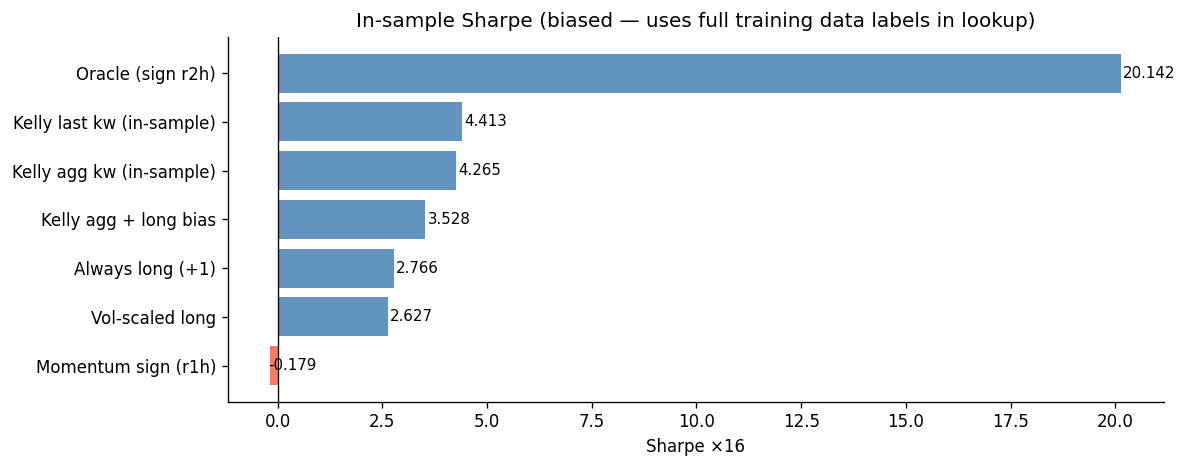

Oracle (sign r2h)            20.142286
Kelly last kw (in-sample)     4.413105
Kelly agg kw (in-sample)      4.264667
Kelly agg + long bias         3.527798
Always long (+1)              2.766061
Vol-scaled long               2.626637
Momentum sign (r1h)          -0.178514


In [11]:
def sharpe(positions, returns, scale=16.0):
    pos = np.asarray(positions, dtype=float)
    ret = np.asarray(returns, dtype=float)
    m   = ~np.isnan(pos) & ~np.isnan(ret)
    pnl = pos[m] * ret[m]
    return pnl.mean() / pnl.std() * scale if pnl.std() > 0 else 0.0


r2h  = train_df['ret2h'].values
vols = train_df['vol_1h'].values
vol_mean = vols.mean()

strategies_is = {
    'Always long (+1)'           : np.ones(len(train_df)),
    'Momentum sign (r1h)'        : np.sign(train_df['ret_1h'].values),
    'Vol-scaled long'            : vol_mean / vols,
    'Kelly last kw (in-sample)'  : train_df['kelly_last'].values,
    'Kelly agg kw (in-sample)'   : train_df['kelly_agg'].values,
    'Kelly agg + long bias'      : 1 + 0.4 * train_df['kelly_agg'].values / train_df['kelly_agg'].std(),
    'Oracle (sign r2h)'          : np.sign(r2h),
}

res_is = {n: sharpe(p, r2h) for n, p in strategies_is.items()}
res_s  = pd.Series(res_is).sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['tomato' if v < 0 else 'steelblue' for v in res_s.values]
ax.barh(res_s.index, res_s.values, color=colors, alpha=0.85)
ax.axvline(0, color='k', lw=0.8)
ax.set_title('In-sample Sharpe (biased — uses full training data labels in lookup)')
ax.set_xlabel('Sharpe ×16')
for i, (n, v) in enumerate(res_s.items()):
    ax.text(v + 0.05*np.sign(v+1e-9), i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()
print(res_s.sort_values(ascending=False).to_string())

## 9. Cross-Validated (OOF) Evaluation

5-fold CV: keyword lookup is rebuilt on each train fold and applied to the held-out fold. No label leakage.

In [12]:
N_FOLDS  = 5
kf       = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
sessions = train_df['session'].values
rets     = train_df['ret2h'].values

oof_ka   = np.zeros(len(sessions))   # kelly_agg OOF
oof_kl   = np.zeros(len(sessions))   # kelly_last OOF
oof_lgb  = np.zeros(len(sessions))   # LightGBM OOF

FEATURE_COLS = [
    'ret_1h', 'vol_1h', 'mom_5', 'mom_10', 'mom_20',
    'close_in_range', 'spread_mean', 'ret_skew', 'slope', 'late_vs_early', 'vol_of_vol',
    'kelly_last', 'kelly_agg', 'kelly_sum', 'mean_ret_agg', 'mr_last', 'n_kw', 'n_owner',
]

lgb_params = dict(
    objective='regression', metric='rmse', n_estimators=300, learning_rate=0.03,
    num_leaves=15, min_data_in_leaf=20, feature_fraction=0.8, bagging_fraction=0.8,
    bagging_freq=1, reg_alpha=0.1, reg_lambda=0.5, verbose=-1, random_state=42,
)

for fold, (tr_idx, val_idx) in enumerate(kf.split(sessions)):
    tr_sess  = sessions[tr_idx]
    val_sess = sessions[val_idx]

    fold_lookup = build_keyword_lookup(
        hl_feats_train[hl_feats_train['session'].isin(tr_sess)],
        target[target['session'].isin(tr_sess)]
    )

    # Keyword OOF
    fold_kw_val = apply_keyword_lookup(
        hl_feats_train[hl_feats_train['session'].isin(val_sess)], fold_lookup
    )
    for i, si in enumerate(val_sess):
        gi = val_idx[i]
        kw_row = fold_kw_val[fold_kw_val['session'] == si]
        if len(kw_row) == 0: continue
        oof_ka[gi] = kw_row['kelly_agg'].iloc[0]
        oof_kl[gi] = kw_row['kelly_last'].iloc[0]

    # LightGBM OOF
    tr_kw  = apply_keyword_lookup(hl_feats_train[hl_feats_train['session'].isin(tr_sess)],  fold_lookup)
    val_kw = apply_keyword_lookup(hl_feats_train[hl_feats_train['session'].isin(val_sess)], fold_lookup)
    tr_df_f  = build_feature_matrix(price_feats_train[price_feats_train['session'].isin(tr_sess)],  tr_kw,  target)
    val_df_f = build_feature_matrix(price_feats_train[price_feats_train['session'].isin(val_sess)], val_kw, target)
    model = lgb.LGBMRegressor(**lgb_params)
    model.fit(tr_df_f[FEATURE_COLS].fillna(0.0).values, tr_df_f['ret2h'].values)
    preds = model.predict(val_df_f[FEATURE_COLS].fillna(0.0).values)
    for i, si in enumerate(val_df_f['session'].values):
        gi = np.where(sessions == si)[0]
        if len(gi) > 0: oof_lgb[gi[0]] = preds[i]

    print(f'  Fold {fold+1}/{N_FOLDS} done')

print()
print('=== OOF Sharpe (cross-validated, unbiased) ===')
print(f'  Always long:               {sharpe(np.ones(len(rets)), rets):+.4f}')
print(f'  Kelly last (OOF):          {sharpe(oof_kl, rets):+.4f}')
print(f'  Kelly agg  (OOF):          {sharpe(oof_ka, rets):+.4f}')
print(f'  LGB vol-scaled (OOF):      {sharpe(oof_lgb * (vol_mean/vols), rets):+.4f}')

  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

=== OOF Sharpe (cross-validated, unbiased) ===
  Always long:               +2.7661
  Kelly last (OOF):          +1.7166
  Kelly agg  (OOF):          +2.5285
  LGB vol-scaled (OOF):      +1.6704


## 10. Optimise the Long-Bias + Kelly Tilt

Position = 1 + γ × (kelly_agg / σ_kelly). γ = 0 → always long; γ = ∞ → pure Kelly.

Kelly_agg stats: mean=7.742  std=7.501


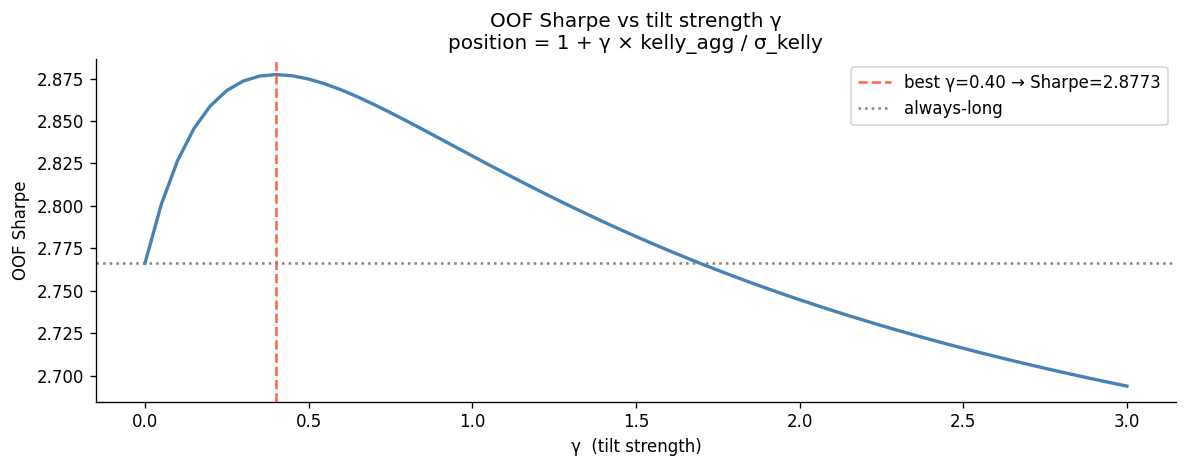

Best γ = 0.40  →  OOF Sharpe = 2.8773


In [13]:
ka_std = np.std(oof_ka[oof_ka != 0])   # std of non-zero kelly_agg values
print(f'Kelly_agg stats: mean={oof_ka.mean():.3f}  std={ka_std:.3f}')

gammas = np.arange(0.0, 3.05, 0.05)
sharpes_tilt = []
for gamma in gammas:
    pos  = 1.0 + gamma * oof_ka / (ka_std + 1e-9)
    sharpes_tilt.append(sharpe(pos, rets))

best_idx   = int(np.argmax(sharpes_tilt))
best_gamma = gammas[best_idx]
best_sharpe_tilt = sharpes_tilt[best_idx]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gammas, sharpes_tilt, lw=2, color='steelblue')
ax.axvline(best_gamma, color='tomato', linestyle='--',
           label=f'best γ={best_gamma:.2f} → Sharpe={best_sharpe_tilt:.4f}')
ax.axhline(sharpe(np.ones(len(rets)), rets), color='gray', linestyle=':', lw=1.5, label='always-long')
ax.set_xlabel('γ  (tilt strength)')
ax.set_ylabel('OOF Sharpe')
ax.set_title('OOF Sharpe vs tilt strength γ\nposition = 1 + γ × kelly_agg / σ_kelly')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Best γ = {best_gamma:.2f}  →  OOF Sharpe = {best_sharpe_tilt:.4f}')

## 11. Final Training Evaluation Summary

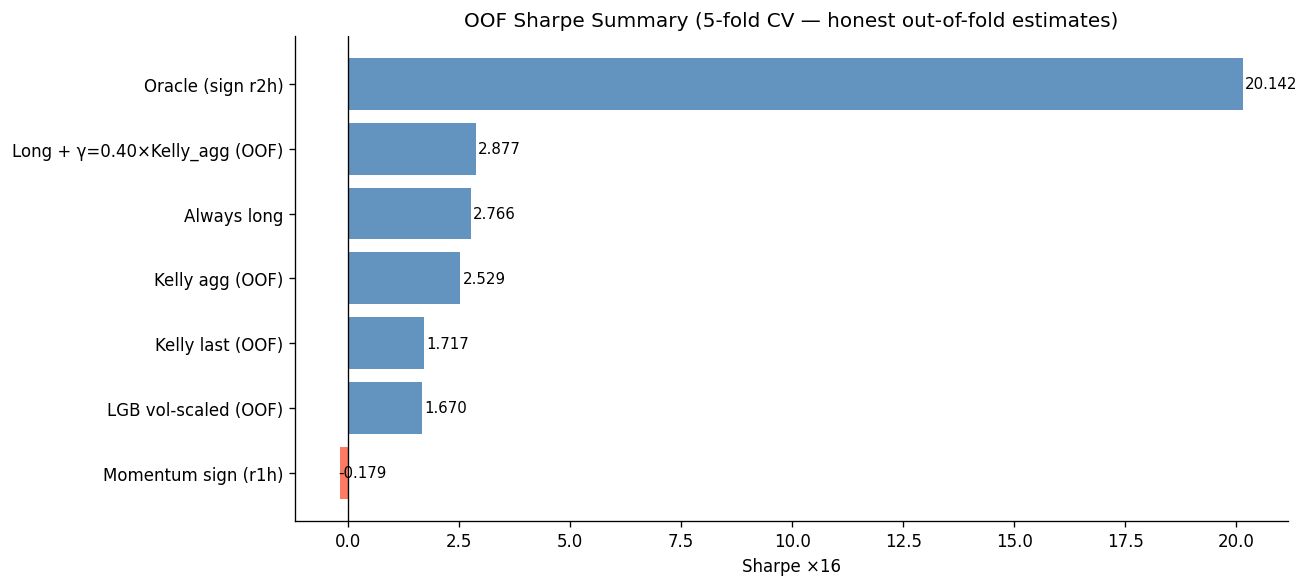

  FINAL OOF SHARPE (training eval): +2.8773
  Mean PnL  : +0.005389
  Std  PnL  : 0.029968
  Win rate  : 56.90%
  Strategy  : pos = 1 + 0.40 × kelly_agg / σ_kelly


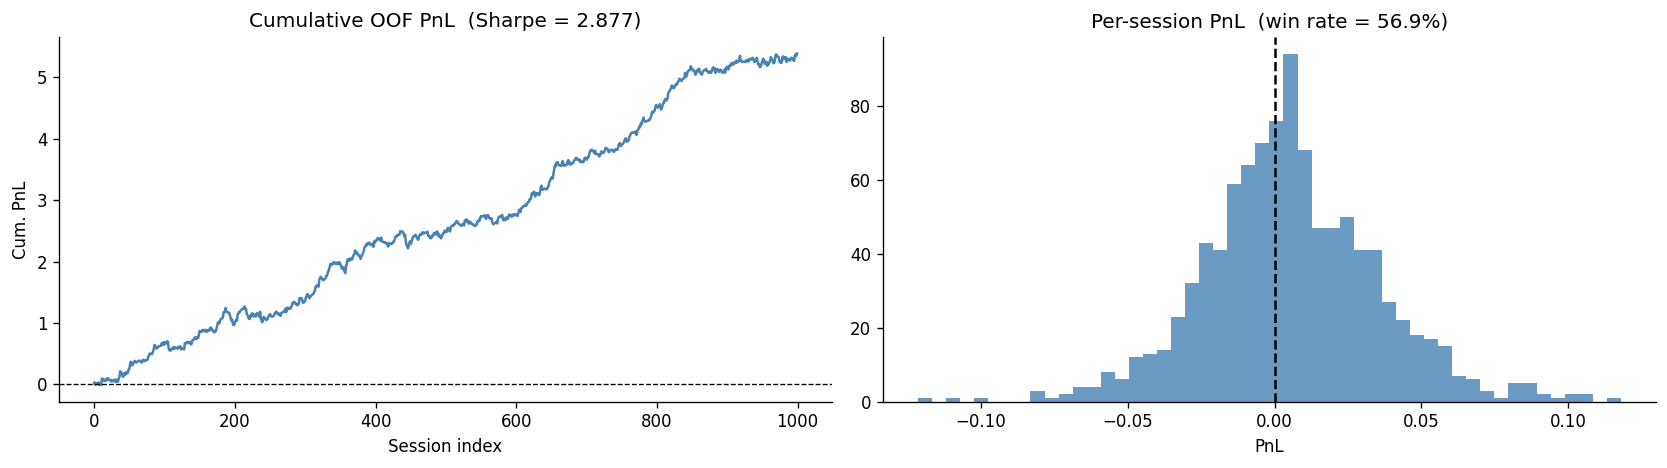

In [14]:
# Final OOF position using best gamma
oof_final = 1.0 + best_gamma * oof_ka / (ka_std + 1e-9)
pnl_final = oof_final * rets
final_sharpe_val = pnl_final.mean() / pnl_final.std() * 16

cv_summary = {
    'Always long'               : sharpe(np.ones(len(rets)), rets),
    'Momentum sign (r1h)'       : sharpe(np.sign(train_df['ret_1h'].values), rets),
    'Kelly last (OOF)'          : sharpe(oof_kl, rets),
    'Kelly agg (OOF)'           : sharpe(oof_ka, rets),
    'LGB vol-scaled (OOF)'      : sharpe(oof_lgb * (vol_mean/vols), rets),
    f'Long + γ={best_gamma:.2f}×Kelly_agg (OOF)': final_sharpe_val,
    'Oracle (sign r2h)'         : sharpe(np.sign(rets), rets),
}

cv_s = pd.Series(cv_summary).sort_values()
fig, ax = plt.subplots(figsize=(11, 5))
colors = ['tomato' if v < 0 else 'steelblue' for v in cv_s.values]
ax.barh(cv_s.index, cv_s.values, color=colors, alpha=0.85)
ax.axvline(0, color='k', lw=0.8)
ax.set_title('OOF Sharpe Summary (5-fold CV — honest out-of-fold estimates)')
ax.set_xlabel('Sharpe ×16')
for i, (n, v) in enumerate(cv_s.items()):
    ax.text(v + 0.05*np.sign(v+1e-9), i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print('=' * 55)
print(f'  FINAL OOF SHARPE (training eval): {final_sharpe_val:+.4f}')
print(f'  Mean PnL  : {pnl_final.mean():+.6f}')
print(f'  Std  PnL  : {pnl_final.std():.6f}')
print(f'  Win rate  : {(pnl_final > 0).mean():.2%}')
print(f'  Strategy  : pos = 1 + {best_gamma:.2f} × kelly_agg / σ_kelly')
print('=' * 55)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(np.cumsum(pnl_final), color='steelblue', lw=1.5)
axes[0].axhline(0, color='k', lw=0.8, linestyle='--')
axes[0].set_title(f'Cumulative OOF PnL  (Sharpe = {final_sharpe_val:.3f})')
axes[0].set_xlabel('Session index'); axes[0].set_ylabel('Cum. PnL')
axes[1].hist(pnl_final, bins=50, color='steelblue', alpha=0.8, edgecolor='none')
axes[1].axvline(0, color='k', linestyle='--')
axes[1].set_title(f'Per-session PnL  (win rate = {(pnl_final>0).mean():.1%})')
axes[1].set_xlabel('PnL')
plt.tight_layout(); plt.show()

## 12. Feature Importance (LightGBM on Full Training Set)

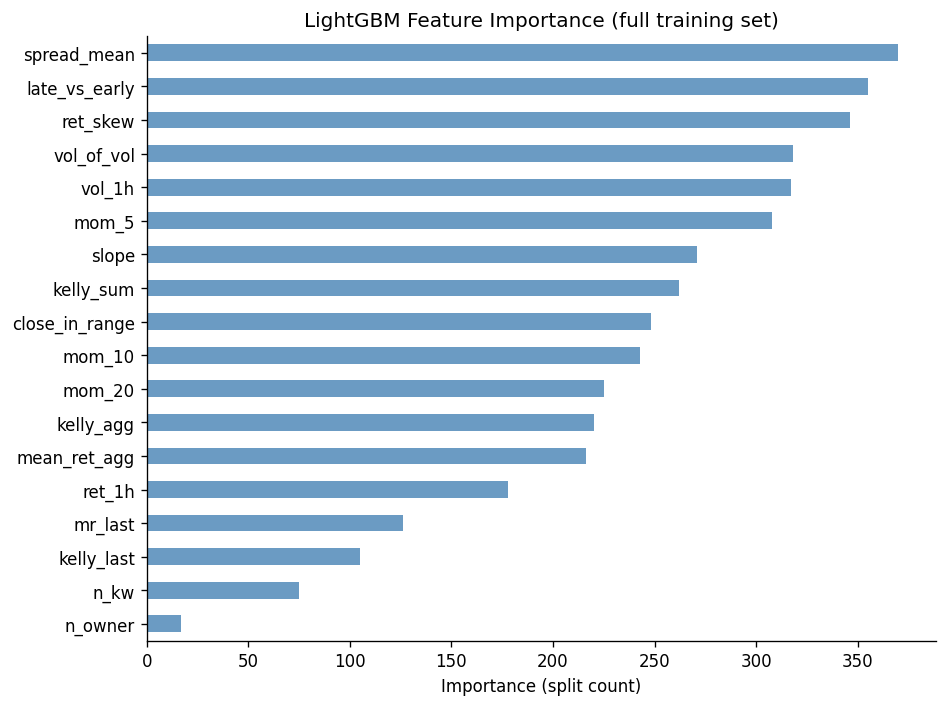

spread_mean       370
late_vs_early     355
ret_skew          346
vol_of_vol        318
vol_1h            317
mom_5             308
slope             271
kelly_sum         262
close_in_range    248
mom_10            243
mom_20            225
kelly_agg         220
mean_ret_agg      216
ret_1h            178
mr_last           126
kelly_last        105
n_kw               75
n_owner            17


In [15]:
full_kw  = apply_keyword_lookup(hl_feats_train, kw_lookup_full)
full_df  = build_feature_matrix(price_feats_train, full_kw, target)
X_full   = full_df[FEATURE_COLS].fillna(0.0).values
y_full   = full_df['ret2h'].values

final_lgb = lgb.LGBMRegressor(**lgb_params)
final_lgb.fit(X_full, y_full)

imp = pd.Series(final_lgb.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
imp.plot.barh(ax=ax, color='steelblue', alpha=0.8)
ax.set_title('LightGBM Feature Importance (full training set)')
ax.set_xlabel('Importance (split count)')
plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).to_string())

## 13. Generate Test Predictions

In [16]:
def predict_split(
    bars_seen   : pd.DataFrame,
    hl_seen     : pd.DataFrame,
    company_df  : pd.DataFrame,
    kw_lookup   : pd.DataFrame,
    gamma       : float,
    ka_std_ref  : float,
) -> pd.DataFrame:
    price_f = extract_price_features(bars_seen)
    hl_f    = extract_headline_features(hl_seen, company_df)
    kw_sig  = apply_keyword_lookup(hl_f, kw_lookup)
    feat_df = build_feature_matrix(price_f, kw_sig)

    pos = 1.0 + gamma * feat_df['kelly_agg'].values / (ka_std_ref + 1e-9)

    out = pd.DataFrame({'session': feat_df['session'].values, 'target_position': pos})
    # Ensure every test session is present (default: always-long = 1.0)
    all_s = pd.DataFrame({'session': bars_seen['session'].unique()})
    out = all_s.merge(out, on='session', how='left').fillna({'target_position': 1.0})
    return out.sort_values('session').reset_index(drop=True)


print('Generating public test predictions...')
pred_pub  = predict_split(bars_seen_pub,  hl_seen_pub,  company_pub,
                          kw_lookup_full, best_gamma, ka_std)

print('Generating private test predictions...')
pred_priv = predict_split(bars_seen_priv, hl_seen_priv, company_priv,
                          kw_lookup_full, best_gamma, ka_std)

print(f'Public  : {len(pred_pub)} sessions')
print(f'Private : {len(pred_priv)} sessions')
print()
print('Public position stats:')
print(pred_pub['target_position'].describe().round(4))
print()
print('Private position stats:')
print(pred_priv['target_position'].describe().round(4))

Generating public test predictions...
Generating private test predictions...
Public  : 10000 sessions
Private : 10000 sessions

Public position stats:
count    10000.0000
mean         1.4135
std          0.3313
min         -0.1672
25%          1.1871
50%          1.4212
75%          1.6550
max          2.1672
Name: target_position, dtype: float64

Private position stats:
count    10000.0000
mean         1.4203
std          0.3291
min         -0.1672
25%          1.1900
50%          1.4230
75%          1.6592
max          2.1672
Name: target_position, dtype: float64


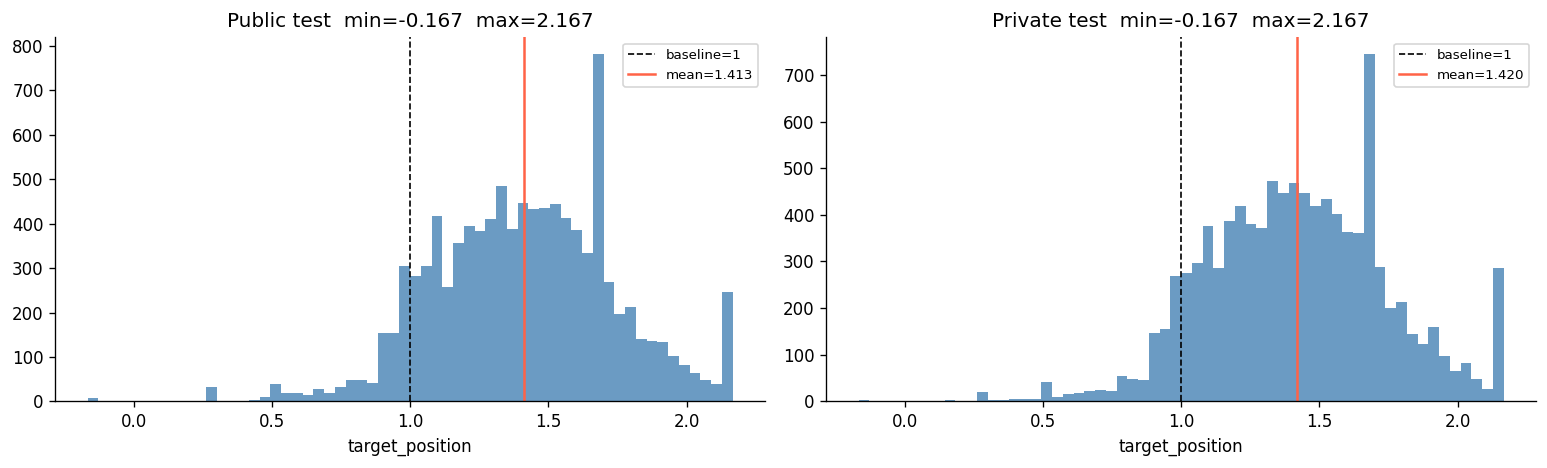

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, pred, label in zip(axes, [pred_pub, pred_priv], ['Public', 'Private']):
    ax.hist(pred['target_position'], bins=60, color='steelblue', alpha=0.8, edgecolor='none')
    ax.axvline(1.0, color='k', linestyle='--', lw=1, label='baseline=1')
    ax.axvline(pred['target_position'].mean(), color='tomato', linestyle='-', lw=1.5,
               label=f"mean={pred['target_position'].mean():.3f}")
    min_p = pred['target_position'].min()
    ax.set_title(f'{label} test  min={min_p:.3f}  max={pred["target_position"].max():.3f}')
    ax.set_xlabel('target_position')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 14. Save Submissions

In [18]:
pred_pub[['session','target_position']].to_csv('submission_public_v2.csv', index=False)
pred_priv[['session','target_position']].to_csv('submission_private_v2.csv', index=False)

combined = pd.concat([pred_pub, pred_priv], ignore_index=True)
combined[['session','target_position']].to_csv('submission_total_v2.csv', index=False)

print('Saved:')
print(f'  submission_public_v2.csv   : {len(pred_pub)} rows')
print(f'  submission_private_v2.csv  : {len(pred_priv)} rows')
print(f'  submission_total_v2.csv    : {len(combined)} rows')
print()
print('Public preview:')
print(pred_pub[['session','target_position']].head(10).to_string(index=False))
print()
print('Private preview:')
print(pred_priv[['session','target_position']].head(10).to_string(index=False))

Saved:
  submission_public_v2.csv   : 10000 rows
  submission_private_v2.csv  : 10000 rows
  submission_total_v2.csv    : 20000 rows

Public preview:
 session  target_position
    1000         1.219056
    1001         1.421677
    1002         1.566446
    1003         1.333676
    1004         1.343179
    1005         1.498262
    1006         1.526708
    1007         1.271675
    1008         1.864688
    1009         0.989386

Private preview:
 session  target_position
   11000         1.492928
   11001         1.470932
   11002         1.265011
   11003         0.889989
   11004         1.048632
   11005         1.550257
   11006         0.970314
   11007         0.308389
   11008         0.949712
   11009         1.662098


In [19]:
import pandas as pd

priv = pd.read_csv("submission_private_v2.csv")
priv

,session,target_position
0,11000,1.492928
1,11001,1.470932
2,11002,1.265011
3,11003,0.889989
4,11004,1.048632
...,...,...
9995,20995,1.040403
9996,20996,1.511153
9997,20997,1.376754
9998,20998,1.751918


In [20]:
pub = pd.read_csv("submission_public_v2.csv")

combined = pd.concat([priv, pub])
print(len(combined))
combined.to_csv("submission_v2.csv")

20000


## 15. Mean Reversion Analysis

Do prices mean-revert within sessions? We check three things:
1. **Hurst exponent** per session (H < 0.5 → mean-reverting, H ≈ 0.5 → random walk, H > 0.5 → trending)
2. **Lag-1 autocorrelation** of bar returns within each session
3. **Conditional 2nd-half return** given 1st-half direction/magnitude (contrarian signal test)

In [21]:
from statsmodels.tsa.stattools import adfuller

def hurst_exponent(ts):
    """R/S analysis Hurst exponent. Returns H in [0,1]."""
    ts = np.array(ts, dtype=float)
    n = len(ts)
    if n < 10:
        return np.nan
    lags = range(2, min(n // 2, 20))
    rs_vals = []
    for lag in lags:
        chunks = [ts[i:i+lag] for i in range(0, n - lag + 1, lag)]
        rs_list = []
        for chunk in chunks:
            mean_c = chunk.mean()
            dev = np.cumsum(chunk - mean_c)
            r = dev.max() - dev.min()
            s = chunk.std(ddof=1)
            if s > 0:
                rs_list.append(r / s)
        if rs_list:
            rs_vals.append((lag, np.mean(rs_list)))
    if len(rs_vals) < 2:
        return np.nan
    lags_arr  = np.log([x[0] for x in rs_vals])
    rs_arr    = np.log([x[1] for x in rs_vals])
    slope, _  = np.polyfit(lags_arr, rs_arr, 1)
    return slope


def session_mean_reversion_stats(bars: pd.DataFrame) -> pd.DataFrame:
    """Per-session: Hurst exponent, lag-1 autocorr of bar returns, ADF p-value."""
    bars = bars.sort_values(['session', 'bar_ix'])
    rows = []
    for sess, grp in bars.groupby('session'):
        close = grp['close'].values
        rets  = np.diff(np.log(close))   # log returns
        if len(rets) < 10:
            continue
        # Hurst on price levels
        H = hurst_exponent(close)
        # Lag-1 autocorr of returns
        if len(rets) > 2:
            ac1 = pd.Series(rets).autocorr(lag=1)
        else:
            ac1 = np.nan
        # ADF test on price levels (unit root → non-stationary; low p → stationary/mean-reverting)
        try:
            adf_p = adfuller(close, autolag='AIC')[1]
        except Exception:
            adf_p = np.nan
        rows.append({'session': sess, 'hurst': H, 'ac1_ret': ac1, 'adf_p': adf_p})
    return pd.DataFrame(rows)


print("Computing per-session mean reversion stats on training seen bars (50 bars each)...")
mr_stats = session_mean_reversion_stats(bars_seen_train)
mr_stats = mr_stats.merge(target[['session', 'ret2h']], on='session', how='left')
print(mr_stats[['hurst', 'ac1_ret', 'adf_p']].describe().round(4))

Computing per-session mean reversion stats on training seen bars (50 bars each)...
           hurst    ac1_ret      adf_p
count  1000.0000  1000.0000  1000.0000
mean      1.0218    -0.0015     0.5057
std       0.0444     0.1376     0.3160
min       0.8283    -0.4436     0.0002
25%       0.9965    -0.0946     0.2242
50%       1.0284     0.0055     0.5125
75%       1.0537     0.0916     0.7931
max       1.1157     0.4394     1.0000


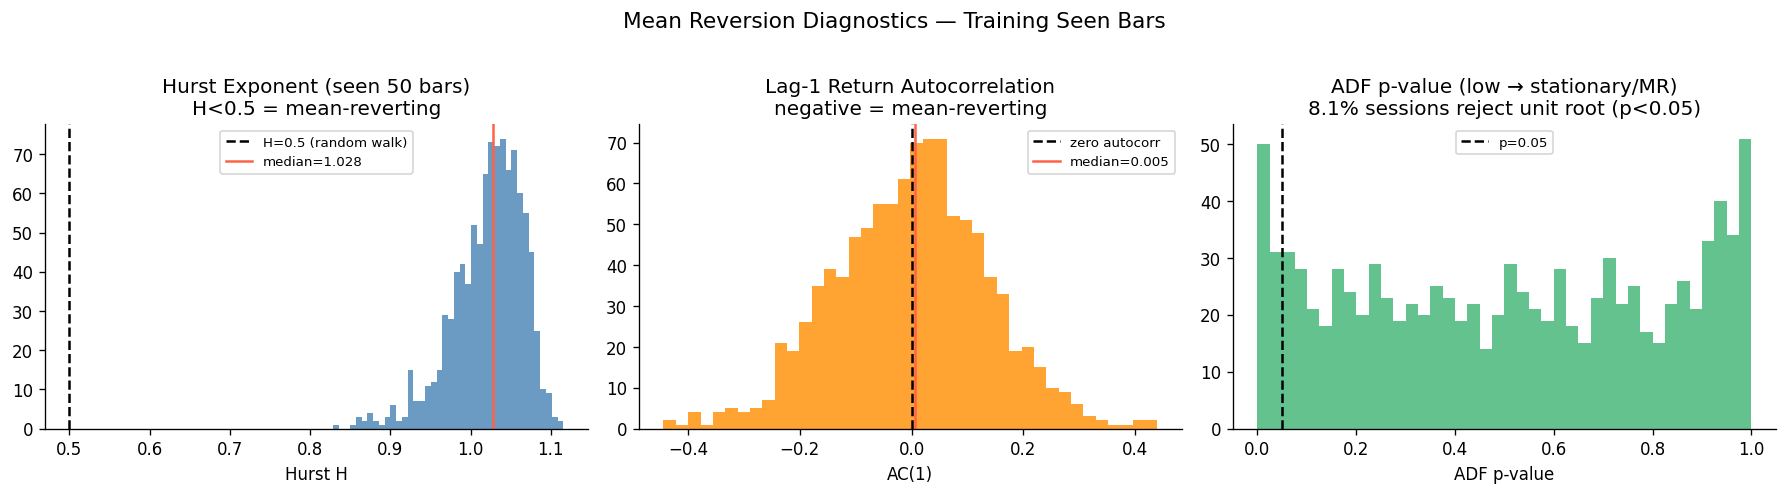

Hurst < 0.5 (mean-reverting):  0.0% of sessions
Hurst > 0.5 (trending):        100.0% of sessions
AC(1) < 0 (mean-reverting):    48.3% of sessions
ADF p < 0.05 (reject RW):      8.1% of sessions


In [22]:
# ── Plot 1: Distribution of Hurst exponents and lag-1 autocorrelations ──────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.hist(mr_stats['hurst'].dropna(), bins=40, color='steelblue', alpha=0.8, edgecolor='none')
ax.axvline(0.5, color='k', linestyle='--', lw=1.5, label='H=0.5 (random walk)')
ax.axvline(mr_stats['hurst'].median(), color='tomato', linestyle='-', lw=1.5,
           label=f"median={mr_stats['hurst'].median():.3f}")
ax.set_title('Hurst Exponent (seen 50 bars)\nH<0.5 = mean-reverting')
ax.set_xlabel('Hurst H'); ax.legend(fontsize=8)

ax = axes[1]
ax.hist(mr_stats['ac1_ret'].dropna(), bins=40, color='darkorange', alpha=0.8, edgecolor='none')
ax.axvline(0, color='k', linestyle='--', lw=1.5, label='zero autocorr')
ax.axvline(mr_stats['ac1_ret'].median(), color='tomato', linestyle='-', lw=1.5,
           label=f"median={mr_stats['ac1_ret'].median():.3f}")
ax.set_title('Lag-1 Return Autocorrelation\nnegative = mean-reverting')
ax.set_xlabel('AC(1)'); ax.legend(fontsize=8)

ax = axes[2]
ax.hist(mr_stats['adf_p'].dropna(), bins=40, color='mediumseagreen', alpha=0.8, edgecolor='none')
ax.axvline(0.05, color='k', linestyle='--', lw=1.5, label='p=0.05')
pct_stationary = (mr_stats['adf_p'] < 0.05).mean()
ax.set_title(f'ADF p-value (low → stationary/MR)\n{pct_stationary:.1%} sessions reject unit root (p<0.05)')
ax.set_xlabel('ADF p-value'); ax.legend(fontsize=8)

plt.suptitle('Mean Reversion Diagnostics — Training Seen Bars', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"Hurst < 0.5 (mean-reverting):  {(mr_stats['hurst'] < 0.5).mean():.1%} of sessions")
print(f"Hurst > 0.5 (trending):        {(mr_stats['hurst'] > 0.5).mean():.1%} of sessions")
print(f"AC(1) < 0 (mean-reverting):    {(mr_stats['ac1_ret'] < 0).mean():.1%} of sessions")
print(f"ADF p < 0.05 (reject RW):      {(mr_stats['adf_p'] < 0.05).mean():.1%} of sessions")

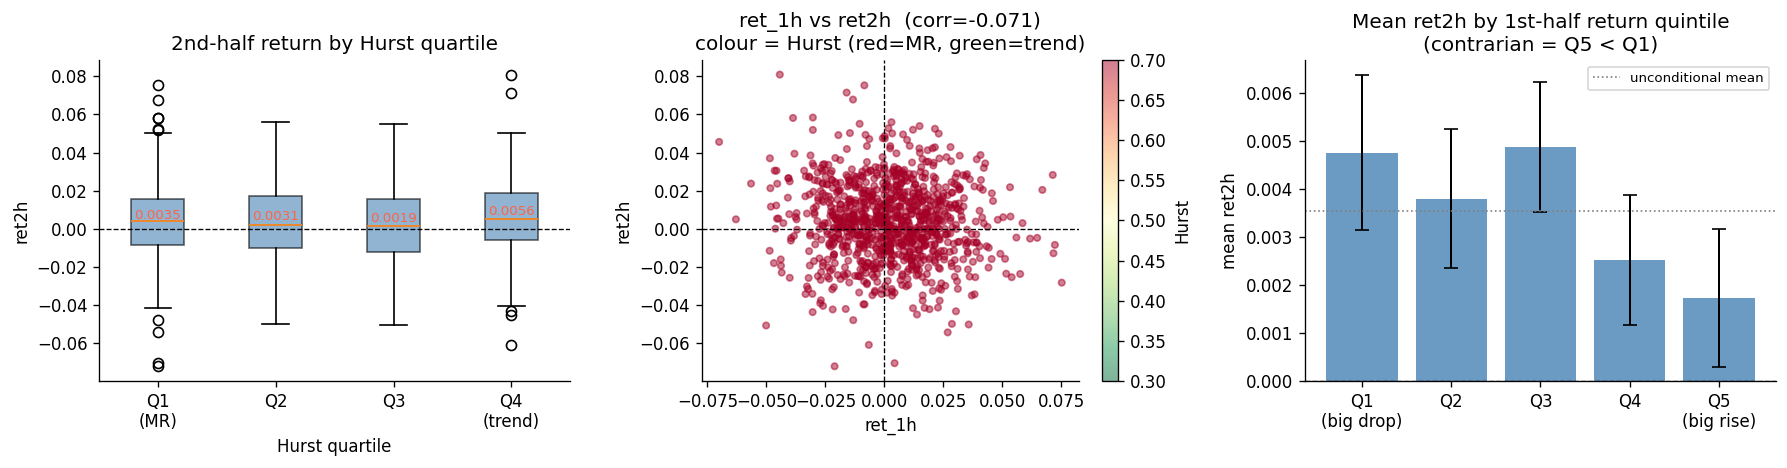

Conditional ret2h stats by 1st-half quintile:
                   mean       se  count
ret1h_q                                
Q1\n(big drop)  0.00475  0.00161    200
Q2              0.00379  0.00144    201
Q3              0.00487  0.00135    200
Q4              0.00251  0.00136    200
Q5\n(big rise)  0.00173  0.00144    199


In [23]:
# ── Plot 2: Does mean reversion in the seen half predict the unseen half? ────
# Split sessions by Hurst quartile and compare mean ret2h

mr_stats['hurst_q'] = pd.qcut(mr_stats['hurst'], q=4, labels=['Q1\n(MR)', 'Q2', 'Q3', 'Q4\n(trend)'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 2a: ret2h by Hurst quartile
ax = axes[0]
groups = [mr_stats[mr_stats['hurst_q'] == q]['ret2h'].dropna() for q in mr_stats['hurst_q'].cat.categories]
ax.boxplot(groups, labels=mr_stats['hurst_q'].cat.categories, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.axhline(0, color='k', lw=0.8, linestyle='--')
ax.set_title('2nd-half return by Hurst quartile')
ax.set_xlabel('Hurst quartile'); ax.set_ylabel('ret2h')
for i, g in enumerate(groups, 1):
    ax.text(i, g.mean(), f'{g.mean():.4f}', ha='center', va='bottom', fontsize=8, color='tomato')

# 2b: Scatter ret_1h vs ret2h, coloured by Hurst
df_scatter = train_df[['session', 'ret_1h', 'ret2h']].merge(mr_stats[['session', 'hurst']], on='session')
sc = axes[1].scatter(df_scatter['ret_1h'], df_scatter['ret2h'],
                     c=df_scatter['hurst'], cmap='RdYlGn_r', alpha=0.5, s=15, vmin=0.3, vmax=0.7)
axes[1].axhline(0, color='k', lw=0.8, linestyle='--')
axes[1].axvline(0, color='k', lw=0.8, linestyle='--')
corr = df_scatter['ret_1h'].corr(df_scatter['ret2h'])
axes[1].set_title(f'ret_1h vs ret2h  (corr={corr:.3f})\ncolour = Hurst (red=MR, green=trend)')
axes[1].set_xlabel('ret_1h'); axes[1].set_ylabel('ret2h')
plt.colorbar(sc, ax=axes[1], label='Hurst')

# 2c: Conditional mean ret2h in extreme 1st-half quintiles (contrarian check)
df_scatter['ret1h_q'] = pd.qcut(df_scatter['ret_1h'], q=5,
                                 labels=['Q1\n(big drop)', 'Q2', 'Q3', 'Q4', 'Q5\n(big rise)'])
cond_means = df_scatter.groupby('ret1h_q', observed=True)['ret2h'].agg(['mean', 'std', 'count'])
cond_means['se'] = cond_means['std'] / np.sqrt(cond_means['count'])
ax = axes[2]
bars = ax.bar(range(5), cond_means['mean'], color=['tomato' if v < 0 else 'steelblue' for v in cond_means['mean']],
              alpha=0.8, yerr=cond_means['se'], capsize=4, error_kw=dict(lw=1.2))
ax.set_xticks(range(5)); ax.set_xticklabels(cond_means.index)
ax.axhline(0, color='k', lw=0.8, linestyle='--')
ax.axhline(target['ret2h'].mean(), color='gray', lw=1, linestyle=':', label='unconditional mean')
ax.set_title('Mean ret2h by 1st-half return quintile\n(contrarian = Q5 < Q1)')
ax.set_ylabel('mean ret2h'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print("Conditional ret2h stats by 1st-half quintile:")
print(cond_means[['mean', 'se', 'count']].round(5).to_string())

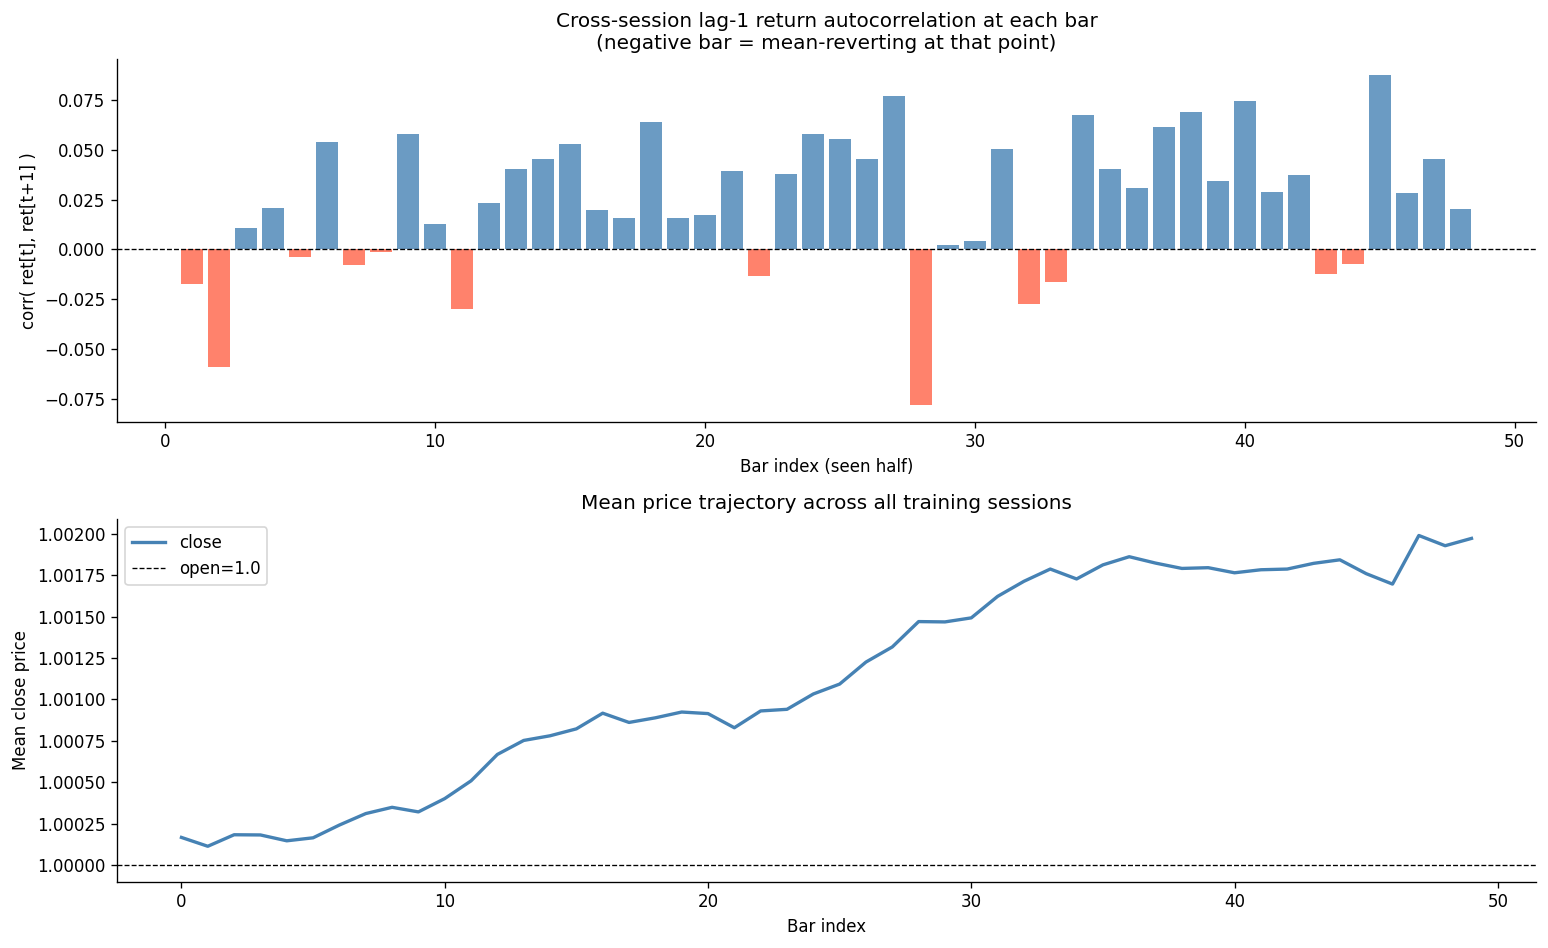


Bars with strongest mean reversion (most negative lag-1 autocorr):
28   -0.0783
2    -0.0589
11   -0.0301
32   -0.0272
1    -0.0174

Bars with strongest momentum (most positive lag-1 autocorr):
45    0.0875
27    0.0774
40    0.0747
38    0.0690
34    0.0677


In [24]:
# ── Plot 3: WHERE in the session does mean reversion happen? ─────────────────
# For each bar t in 0..48, compute autocorrelation of ret[t] with ret[t+1]
# across sessions — tells us at which bar returns flip sign most often.

bars_sorted = bars_seen_train.sort_values(['session', 'bar_ix']).copy()
bars_sorted['log_ret'] = bars_sorted.groupby('session')['close'].transform(
    lambda x: np.log(x).diff()
)

# Pivot to (session × bar_ix) matrix of log returns
ret_matrix = bars_sorted.pivot(index='session', columns='bar_ix', values='log_ret')
# Drop bar 0 (NaN from diff) → bars 1..49
ret_matrix = ret_matrix.loc[:, 1:49]

# Lag-1 cross-session correlation at each bar: corr(ret[t], ret[t+1])
lag1_by_bar = {}
for t in range(1, 49):
    r_t   = ret_matrix[t].dropna()
    r_t1  = ret_matrix[t + 1].dropna()
    common = r_t.index.intersection(r_t1.index)
    if len(common) > 10:
        lag1_by_bar[t] = r_t[common].corr(r_t1[common])

lag1_series = pd.Series(lag1_by_bar)

# Mean absolute price deviation from session open, to see if reversion tracks distance
# Average trajectory: mean price at each bar
mean_price_by_bar = bars_seen_train.groupby('bar_ix')['close'].mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

ax = axes[0]
colors_bar = ['tomato' if v < 0 else 'steelblue' for v in lag1_series.values]
ax.bar(lag1_series.index, lag1_series.values, color=colors_bar, alpha=0.8, width=0.8)
ax.axhline(0, color='k', lw=0.8, linestyle='--')
ax.set_title('Cross-session lag-1 return autocorrelation at each bar\n'
             '(negative bar = mean-reverting at that point)')
ax.set_xlabel('Bar index (seen half)'); ax.set_ylabel('corr( ret[t], ret[t+1] )')

ax = axes[1]
mean_price_by_bar.plot(ax=ax, color='steelblue', lw=2)
ax.axhline(1.0, color='k', lw=0.8, linestyle='--', label='open=1.0')
ax.set_title('Mean price trajectory across all training sessions')
ax.set_xlabel('Bar index'); ax.set_ylabel('Mean close price'); ax.legend()

plt.tight_layout(); plt.show()

print(f"\nBars with strongest mean reversion (most negative lag-1 autocorr):")
print(lag1_series.nsmallest(5).round(4).to_string())
print(f"\nBars with strongest momentum (most positive lag-1 autocorr):")
print(lag1_series.nlargest(5).round(4).to_string())

In [25]:
# ── Sharpe test: can Hurst or AC(1) improve our position sizing? ─────────────
# Idea: go more contrarian when session shows mean reversion (low Hurst)

df_mr = train_df[['session', 'ret2h', 'ret_1h', 'vol_1h']].merge(
    mr_stats[['session', 'hurst', 'ac1_ret']], on='session', how='left'
)
df_mr = df_mr.dropna(subset=['hurst', 'ac1_ret'])

rets_mr = df_mr['ret2h'].values
vols_mr = df_mr['vol_1h'].values
ret1h   = df_mr['ret_1h'].values
H       = df_mr['hurst'].values
ac1     = df_mr['ac1_ret'].values

print("=== Sharpe of mean-reversion-conditioned strategies ===\n")

# Baseline
print(f"Always long:                      {sharpe(np.ones(len(rets_mr)), rets_mr):+.4f}")

# Contrarian (fade 1st half) — pure
contr = -np.sign(ret1h)
print(f"Pure contrarian (-sign ret1h):    {sharpe(contr, rets_mr):+.4f}")

# Momentum (follow 1st half)
print(f"Pure momentum  (+sign ret1h):     {sharpe(np.sign(ret1h), rets_mr):+.4f}")

# Contrarian only when H < 0.5 (mean-reverting session), else always long
pos_hurst_contr = np.where(H < 0.5, -np.sign(ret1h), 1.0)
print(f"Contrarian if H<0.5, else long:   {sharpe(pos_hurst_contr, rets_mr):+.4f}")

# Contrarian only when AC(1) < 0 (mean-reverting session), else always long
pos_ac1_contr = np.where(ac1 < 0, -np.sign(ret1h), 1.0)
print(f"Contrarian if AC1<0, else long:   {sharpe(pos_ac1_contr, rets_mr):+.4f}")

# Size by |H - 0.5|: stronger tilt when more clearly MR or trending
mr_signal = (0.5 - H)  # positive when MR, negative when trending
pos_mr_size = 1.0 + 0.3 * mr_signal * (-np.sign(ret1h))  # fade harder when clearly MR
print(f"Long + MR-scaled contrarian:      {sharpe(pos_mr_size, rets_mr):+.4f}")

# Combined: Hurst MR signal × contrarian + always-long base
print()
print("Note: in-sample (biased). Compare direction only — not for production.")

=== Sharpe of mean-reversion-conditioned strategies ===

Always long:                      +2.7661
Pure contrarian (-sign ret1h):    +0.1785
Pure momentum  (+sign ret1h):     -0.1785
Contrarian if H<0.5, else long:   +2.7661
Contrarian if AC1<0, else long:   +1.5620
Long + MR-scaled contrarian:      +2.6975

Note: in-sample (biased). Compare direction only — not for production.


## 16. Classification Quality Investigation

**Approach 2:** Confidence-gated signal — use keyword tilt only when Igor's classifier is confident (high `score_margin`), fall back to always-long otherwise.

**Approach 3:** No classification — aggregate keywords from *all* companies in the session. Owner's signal always included; non-owner noise gets averaged out.

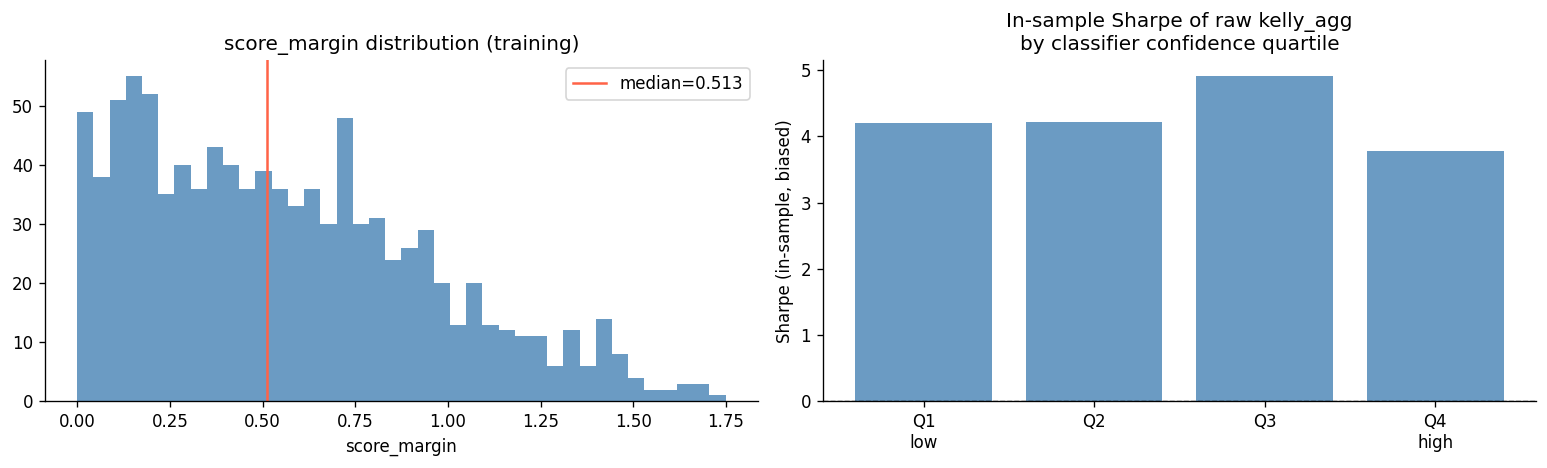

  conf_q  sharpe_ka
 Q1\nlow   4.204948
      Q2   4.221851
      Q3   4.905828
Q4\nhigh   3.782733


In [26]:
# Load confidence scores from Igor's classifier
conf_train = company_all[company_all['split']=='train'][['session','score_margin']].reset_index(drop=True)

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(conf_train['score_margin'], bins=40, color='steelblue', alpha=0.8, edgecolor='none')
axes[0].axvline(conf_train['score_margin'].median(), color='tomato', lw=1.5,
                label=f"median={conf_train['score_margin'].median():.3f}")
axes[0].set_title('score_margin distribution (training)')
axes[0].set_xlabel('score_margin'); axes[0].legend()

# Does higher confidence correlate with stronger keyword signal?
df_conf = train_df[['session','kelly_agg','ret2h']].merge(conf_train, on='session')
df_conf['conf_q'] = pd.qcut(df_conf['score_margin'], q=4,
                             labels=['Q1\nlow', 'Q2', 'Q3', 'Q4\nhigh'])
grp = df_conf.groupby('conf_q', observed=True).apply(
    lambda g: sharpe(g['kelly_agg'].values, g['ret2h'].values)
).reset_index()
grp.columns = ['conf_q', 'sharpe_ka']
axes[1].bar(range(4), grp['sharpe_ka'],
            color=['tomato' if v < 0 else 'steelblue' for v in grp['sharpe_ka']], alpha=0.8)
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(grp['conf_q'])
axes[1].axhline(0, color='k', lw=0.8, linestyle='--')
axes[1].set_title('In-sample Sharpe of raw kelly_agg\nby classifier confidence quartile')
axes[1].set_ylabel('Sharpe (in-sample, biased)')

plt.tight_layout(); plt.show()
print(grp.to_string(index=False))

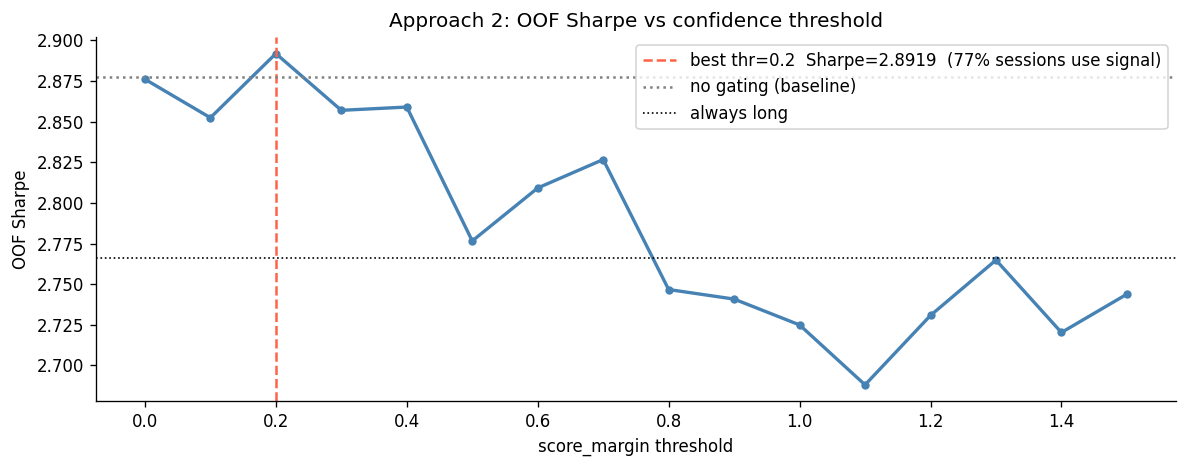

Always long:              +2.7661
Kelly agg (no gating):    +2.8773
Kelly agg (best gating):  +2.8919  (threshold=0.2, 77% sessions)


In [27]:
# ── Approach 2: OOF — confidence-gated keyword signal ───────────────────────
# For each fold: apply kelly_agg only when score_margin > threshold,
# else position = 1 (always long). Grid-search the threshold.

thresholds = np.arange(0.0, 1.6, 0.1)

# We already have oof_ka from section 9; we need per-session score_margin
sessions_arr = train_df['session'].values
rets_arr     = train_df['ret2h'].values
margins      = conf_train.set_index('session')['score_margin']
margin_arr   = np.array([margins.get(s, 0.0) for s in sessions_arr])

ka_std_oof = np.std(oof_ka[oof_ka != 0])

sharpes_thresh = []
for thr in thresholds:
    high_conf = margin_arr >= thr
    pos = np.where(high_conf,
                   1.0 + best_gamma * oof_ka / (ka_std_oof + 1e-9),
                   1.0)
    sharpes_thresh.append(sharpe(pos, rets_arr))

best_thr_idx  = int(np.argmax(sharpes_thresh))
best_thr      = thresholds[best_thr_idx]
best_thr_sh   = sharpes_thresh[best_thr_idx]
pct_high_conf = (margin_arr >= best_thr).mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, sharpes_thresh, lw=2, color='steelblue', marker='o', ms=4)
ax.axvline(best_thr, color='tomato', linestyle='--',
           label=f'best thr={best_thr:.1f}  Sharpe={best_thr_sh:.4f}  ({pct_high_conf:.0%} sessions use signal)')
ax.axhline(sharpe(1.0 + best_gamma * oof_ka / (ka_std_oof + 1e-9), rets_arr),
           color='gray', linestyle=':', lw=1.5, label='no gating (baseline)')
ax.axhline(sharpe(np.ones(len(rets_arr)), rets_arr),
           color='k', linestyle=':', lw=1, label='always long')
ax.set_xlabel('score_margin threshold'); ax.set_ylabel('OOF Sharpe')
ax.set_title('Approach 2: OOF Sharpe vs confidence threshold')
ax.legend(); plt.tight_layout(); plt.show()

print(f"Always long:              {sharpe(np.ones(len(rets_arr)), rets_arr):+.4f}")
print(f"Kelly agg (no gating):    {sharpe(1.0 + best_gamma * oof_ka / (ka_std_oof+1e-9), rets_arr):+.4f}")
print(f"Kelly agg (best gating):  {best_thr_sh:+.4f}  (threshold={best_thr:.1f}, {pct_high_conf:.0%} sessions)")

In [28]:
# ── Approach 3: All-company keywords (no classification) ────────────────────

def extract_headline_features_all(headlines: pd.DataFrame) -> pd.DataFrame:
    """Extract keywords from ALL companies in the session (no owner filtering)."""
    hl = headlines.copy()
    hl['keyword'] = hl['headline'].apply(extract_keyword)
    results = []
    for sess in headlines['session'].unique():
        sess_hl  = hl[hl['session'] == sess].sort_values('bar_ix')
        kw_rows  = sess_hl.dropna(subset=['keyword'])
        last_kw  = kw_rows.iloc[-1]['keyword'] if len(kw_rows) > 0 else None
        kw_list  = list(kw_rows[['bar_ix','keyword']].itertuples(index=False, name=None))
        results.append({
            'session' : sess,
            'n_owner' : len(sess_hl),
            'n_kw'    : len(kw_rows),
            'n_total' : len(sess_hl),
            'last_kw' : last_kw,
            'kw_list' : kw_list,
        })
    return pd.DataFrame(results)


hl_feats_all_train = extract_headline_features_all(hl_seen_train)
hl_feats_all_pub   = extract_headline_features_all(hl_seen_pub)
hl_feats_all_priv  = extract_headline_features_all(hl_seen_priv)

print('All-company headline features (train):', hl_feats_all_train.shape)
print(f"Mean keywords per session: {hl_feats_all_train['n_kw'].mean():.1f}  "
      f"(vs {hl_feats_train['n_kw'].mean():.1f} owner-only)")

All-company headline features (train): (1000, 6)
Mean keywords per session: 9.7  (vs 2.9 owner-only)


In [29]:
# ── OOF for Approach 3 ───────────────────────────────────────────────────────
oof_ka_all = np.zeros(len(sessions))
oof_kl_all = np.zeros(len(sessions))

for fold, (tr_idx, val_idx) in enumerate(kf.split(sessions)):
    tr_sess  = sessions[tr_idx]
    val_sess = sessions[val_idx]

    fold_lookup_all = build_keyword_lookup(
        hl_feats_all_train[hl_feats_all_train['session'].isin(tr_sess)],
        target[target['session'].isin(tr_sess)]
    )
    fold_kw_val_all = apply_keyword_lookup(
        hl_feats_all_train[hl_feats_all_train['session'].isin(val_sess)],
        fold_lookup_all
    )
    for i, si in enumerate(val_sess):
        gi = val_idx[i]
        row = fold_kw_val_all[fold_kw_val_all['session'] == si]
        if len(row) == 0: continue
        oof_ka_all[gi] = row['kelly_agg'].iloc[0]
        oof_kl_all[gi] = row['kelly_last'].iloc[0]

    print(f'  Fold {fold+1}/{N_FOLDS} done')

ka_std_all = np.std(oof_ka_all[oof_ka_all != 0])

# Optimise gamma for approach 3
sharpes_all = []
for gamma in gammas:
    pos = 1.0 + gamma * oof_ka_all / (ka_std_all + 1e-9)
    sharpes_all.append(sharpe(pos, rets))

best_idx_all   = int(np.argmax(sharpes_all))
best_gamma_all = gammas[best_idx_all]
best_sh_all    = sharpes_all[best_idx_all]

print()
print('=== OOF Sharpe Comparison ===')
print(f'  Always long:                    {sharpe(np.ones(len(rets)), rets):+.4f}')
print(f'  Approach original (owner kw):   {sharpe(1.0 + best_gamma * oof_ka / (ka_std_oof+1e-9), rets):+.4f}  γ={best_gamma:.2f}')
print(f'  Approach 2 (conf-gated):        {best_thr_sh:+.4f}  thr={best_thr:.1f}')
print(f'  Approach 3 (all companies):     {best_sh_all:+.4f}  γ={best_gamma_all:.2f}')

  Fold 1/5 done
  Fold 2/5 done
  Fold 3/5 done
  Fold 4/5 done
  Fold 5/5 done

=== OOF Sharpe Comparison ===
  Always long:                    +2.7661
  Approach original (owner kw):   +2.8773  γ=0.40
  Approach 2 (conf-gated):        +2.8919  thr=0.2
  Approach 3 (all companies):     +2.8604  γ=0.50


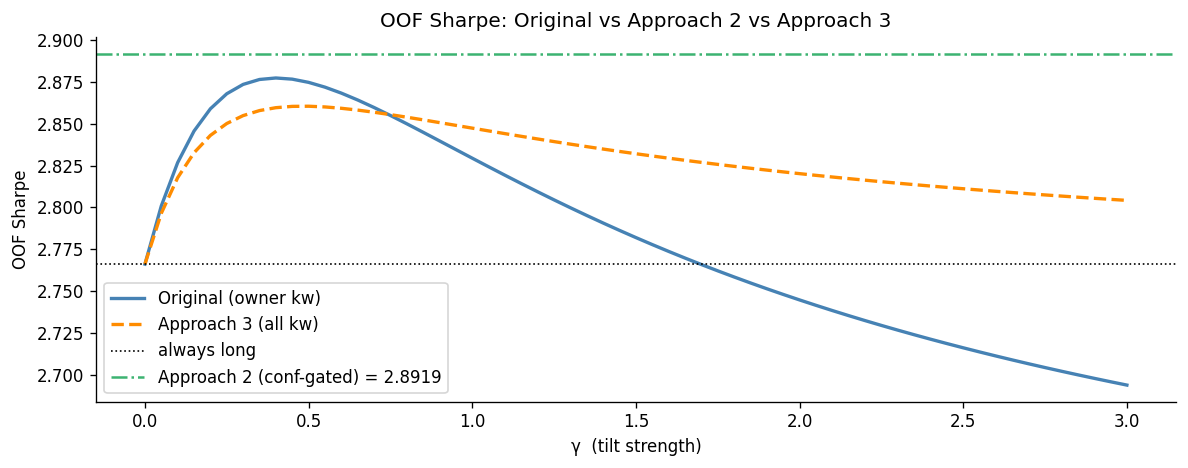

  Approach 3 + conf gating:       +2.8917


In [30]:
# ── Visual comparison ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gammas, sharpes_tilt, lw=2, label='Original (owner kw)', color='steelblue')
ax.plot(gammas, sharpes_all,  lw=2, label='Approach 3 (all kw)',  color='darkorange', linestyle='--')
ax.axhline(sharpe(np.ones(len(rets)), rets), color='k', linestyle=':', lw=1, label='always long')
ax.axhline(best_thr_sh, color='mediumseagreen', linestyle='-.', lw=1.5,
           label=f'Approach 2 (conf-gated) = {best_thr_sh:.4f}')
ax.set_xlabel('γ  (tilt strength)'); ax.set_ylabel('OOF Sharpe')
ax.set_title('OOF Sharpe: Original vs Approach 2 vs Approach 3')
ax.legend(); plt.tight_layout(); plt.show()

# Combine: approach 3 signal + confidence gating
pos_combined = np.where(
    margin_arr >= best_thr,
    1.0 + best_gamma_all * oof_ka_all / (ka_std_all + 1e-9),
    1.0
)
print(f'  Approach 3 + conf gating:       {sharpe(pos_combined, rets):+.4f}')